# **1. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

# **2. Memuat Dataset dari Hasil Clustering**

Memuat dataset hasil clustering dari file CSV ke dalam variabel DataFrame.

In [2]:
# Memuat dataset hasil clustering dari GitHub
df = pd.read_csv('https://raw.githubusercontent.com/Meicha15/Submission-Clastering/refs/heads/main/hasil_clustering.csv')
df.head()

,Negara,Tahun,Schizophrenia disorders,Depressive disorders,Anxiety disorders,Bipolar disorders,Eating disorders,Cluster
0,Afghanistan,1990.0,0.223206,4.996118,4.713314,0.703023,0.127700,2
1,Afghanistan,1991.0,0.222454,4.989290,4.702100,0.702069,0.123256,2
2,Afghanistan,1992.0,0.221751,4.981346,4.683743,0.700792,0.118844,2
3,Afghanistan,1993.0,0.220987,4.976958,4.673549,0.700087,0.115089,2
4,Afghanistan,1994.0,0.220183,4.977782,4.670810,0.699898,0.111815,2


In [3]:
#Menampilkan informasi pada dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5792 entries, 0 to 5791
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Negara                   5792 non-null   object 
 1   Tahun                    5792 non-null   float64
 2   Schizophrenia disorders  5792 non-null   float64
 3   Depressive disorders     5792 non-null   float64
 4   Anxiety disorders        5792 non-null   float64
 5   Bipolar disorders        5792 non-null   float64
 6   Eating disorders         5792 non-null   float64
 7   Cluster                  5792 non-null   int64  
dtypes: float64(6), int64(1), object(1)
memory usage: 362.1+ KB


In [4]:
df.describe()

,Tahun,Schizophrenia disorders,Depressive disorders,Anxiety disorders,Bipolar disorders,Eating disorders,Cluster
count,5792.000000,5792.000000,5792.000000,5792.000000,5792.000000,5792.000000,5792.000000
mean,2004.353246,0.262431,3.711095,3.888694,0.610105,0.168984,0.932320
std,8.683495,0.034044,0.885685,0.801726,0.221282,0.101064,0.780246
min,1990.000000,0.188416,1.522333,1.879996,0.181667,0.044780,0.000000
25%,1997.000000,0.230379,3.046987,3.372461,0.511341,0.094027,0.000000
50%,2004.000000,0.272335,3.594057,3.858950,0.553862,0.133162,1.000000
75%,2012.000000,0.285373,4.350564,4.308883,0.796807,0.204260,2.000000
max,2019.000000,0.345895,6.277466,6.271558,1.112766,0.482690,2.000000


In [5]:
#Melihat missing value dan duplikasi data
print('Jumlah missing value pada dataset: ', df.isnull().sum().sum())
print('Jumlah duplikasi data pada dataset: ', df.duplicated().sum())

Jumlah missing value pada dataset:  0
Jumlah duplikasi data pada dataset:  0


<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

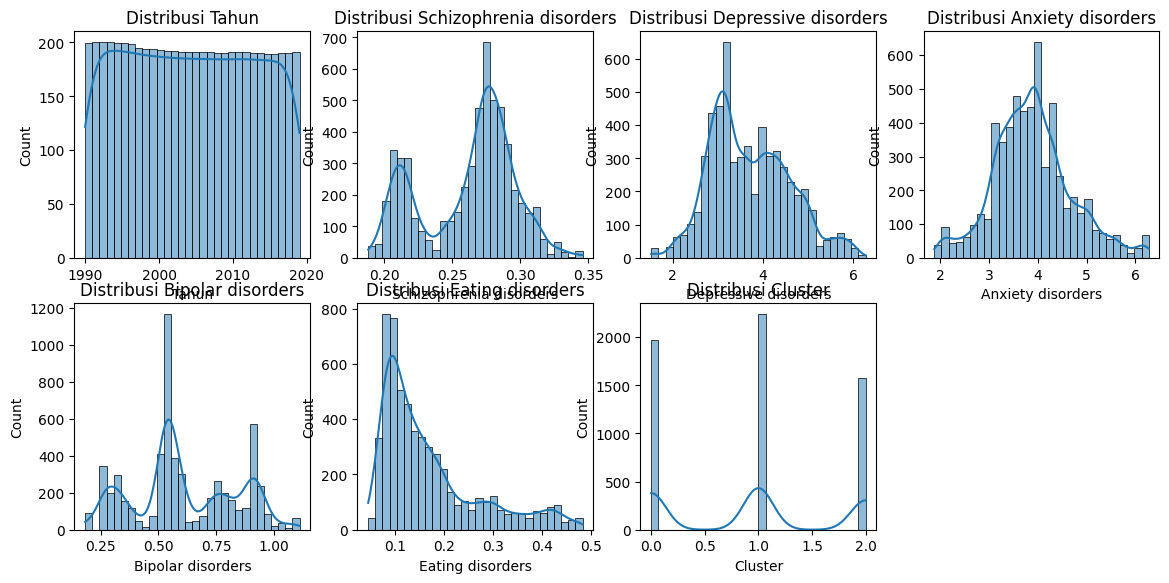

In [6]:
# Visualisasi distribusi fitur numerik pada dataset
numeric_features = df.select_dtypes(include=[np.number])
plt.figure(figsize=(14,10))
for i, column in enumerate(numeric_features.columns, 1):
    plt.subplot(3, 4, i)
    sns.histplot(df[column], bins= 30, kde=True)
    plt.title(f'Distribusi {column}')
plt.tight_layout

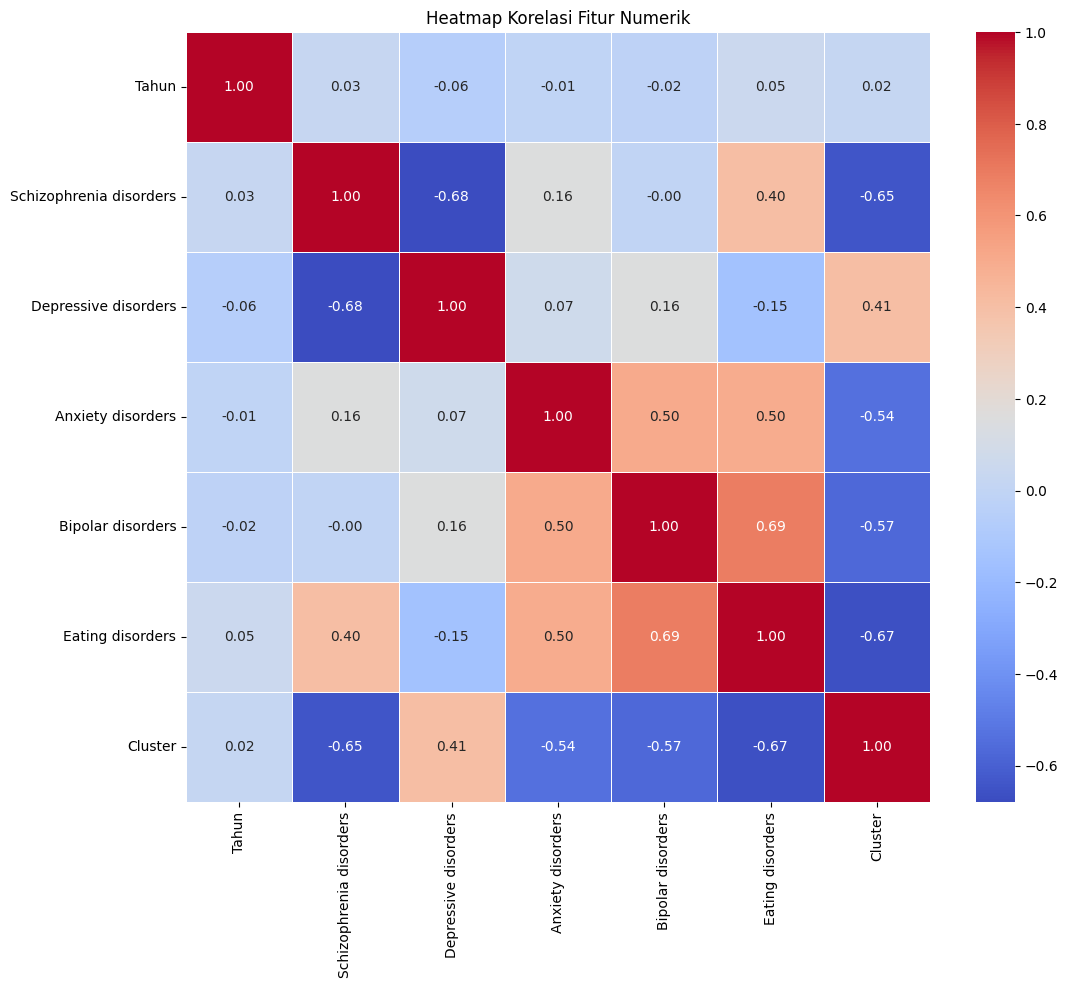

In [7]:
#Heatmap korelasi untuk fitur numerik
plt.figure(figsize=(12,10))
correlation_matrix = numeric_features.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Fitur Numerik')
plt.show()

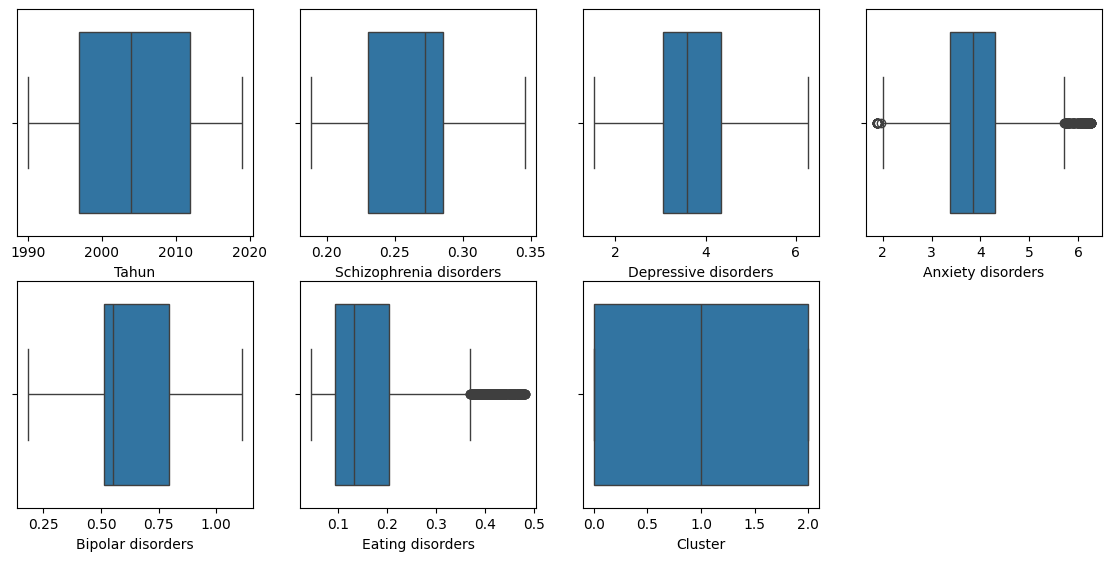

In [8]:
#Melihat outlier dengan boxplot
plt.figure(figsize=(14,10))
for i, column in enumerate(numeric_features.columns, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(x=df[column])

In [9]:
#Hapus kolom "Negara" dan "Tahun" pada dataset
df = df.drop(columns=['Negara','Tahun'])

In [10]:
#Menampilkan hasil
df.head()

,Schizophrenia disorders,Depressive disorders,Anxiety disorders,Bipolar disorders,Eating disorders,Cluster
0,0.223206,4.996118,4.713314,0.703023,0.127700,2
1,0.222454,4.989290,4.702100,0.702069,0.123256,2
2,0.221751,4.981346,4.683743,0.700792,0.118844,2
3,0.220987,4.976958,4.673549,0.700087,0.115089,2
4,0.220183,4.977782,4.670810,0.699898,0.111815,2


# **3. Data Splitting**

Tahap Data Splitting bertujuan untuk memisahkan dataset menjadi dua bagian: data latih (training set) dan data uji (test set).

In [11]:
#Split data menjadi data pelatihan dan data uji
X = df.drop(columns=['Cluster'])
y = df['Cluster']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
#Menampilkan jumlah data latih dan data uji
print("Jumlah data latih:", len(X_train))
print("Jumlah data uji:", len(X_test))

Jumlah data latih: 4633
Jumlah data uji: 1159


In [13]:
#Tampilkan bentuk set pelatihan dan set uji untuk memastikan split
print(f'Training set shape : X_train = {X_train.shape}, y_train = {y_train.shape}')
print(f'Testing set shape : X_test = {X_test.shape}, y_test = {y_test.shape}')

Training set shape : X_train = (4633, 5), y_train = (4633,)
Testing set shape : X_test = (1159, 5), y_test = (1159,)


In [14]:
#Cek semua tipe data
print(df.dtypes)

Schizophrenia disorders    float64
Depressive disorders       float64
Anxiety disorders          float64
Bipolar disorders          float64
Eating disorders           float64
Cluster                      int64
dtype: object


# **4. Membangun Model Klasifikasi**


## **a. Membangun Model Klasifikasi**

Setelah memilih algoritma klasifikasi yang sesuai, langkah selanjutnya adalah melatih model menggunakan data latih.

Berikut adalah rekomendasi tahapannya.
1. Pilih algoritma klasifikasi yang sesuai, seperti Logistic Regression, Decision Tree, Random Forest, atau K-Nearest Neighbors (KNN).
2. Latih model menggunakan data latih.

In [15]:
#Melatih dataset menggunakan model Decision Tree
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [16]:
#Melatih dataset menggunakan model Random Forest
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Tulis narasi atau penjelasan algoritma yang Anda gunakan.

## **b. Evaluasi Model Klasifikasi**

Berikut adalah **rekomendasi** tahapannya.
1. Lakukan prediksi menggunakan data uji.
2. Hitung metrik evaluasi seperti Accuracy dan F1-Score (Opsional: Precision dan Recall).
3. Buat confusion matrix untuk melihat detail prediksi benar dan salah.

In [17]:
#Mengevaluasi model Dicision Tree
y_pred = dt_classifier.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred)
f1_dt = f1_score(y_test, y_pred, average='weighted')
recall_dt = recall_score(y_test, y_pred, average='weighted')

In [18]:
#Menampilkan hasil evaluasi model Decision Tree
print(f'Accuracy: {accuracy_dt}')
print(f'F1-Score: {f1_dt}')
print(f'Recall: {recall_dt}')

Accuracy: 0.997411561691113
F1-Score: 0.997411561691113
Recall: 0.997411561691113


In [19]:
#Mengevaluasi model Random Forest
y_pred = rf_classifier.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred)
f1_rf = f1_score(y_test, y_pred, average='weighted')
recall_rf = recall_score(y_test, y_pred, average='weighted')

In [20]:
#Menampilkan hasil evaluasi model Random Forest
print(f'Accuracy: {accuracy_rf}')
print(f'F1-Score: {f1_rf}')
print(f'Recall: {recall_rf}')

Accuracy: 0.998274374460742
F1-Score: 0.9982741868568743
Recall: 0.998274374460742


In [21]:
#Membuat DataFrame untuk meringkas hasil accuracy, f1score, dan recall untuk semua model
results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Accuracy': [accuracy_dt, accuracy_rf],
    'F1-Score': [f1_dt, f1_rf],
    'Recall': [recall_dt, recall_rf]})


In [22]:
#Konversi daftar kamus ke DataFrame
results_df = pd.DataFrame(results)

Tulis hasil evaluasi algoritma yang digunakan, jika Anda menggunakan 2 algoritma, maka bandingkan hasilnya.

## **c. Tuning Model Klasifikasi (Optional)**

Gunakan GridSearchCV, RandomizedSearchCV, atau metode lainnya untuk mencari kombinasi hyperparameter terbaik

In [23]:
from sklearn.ensemble import RandomForestClassifier

# Inisialisasi model Random Forest tanpa hyperparameter tuning
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Evaluasi awal model tanpa tuning
initial_score_rf = rf.score(X_test, y_test)
print(f"Initial accuracy on test set (without tuning): {initial_score_rf}")

#Evaluasi awal model tanpa tunning menggunakan f1 score
from sklearn.metrics import f1_score
y_pred = rf.predict(X_test)
f1_initial_rf = f1_score(y_test, y_pred, average='weighted')
print(f"Initial F1-score on test set (without tuning): {f1_initial_rf}")

Initial accuracy on test set (without tuning): 0.998274374460742
Initial F1-score on test set (without tuning): 0.9982741868568743


In [24]:
from sklearn.model_selection import GridSearchCV

# Definisikan parameter grid untuk Grid Search
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# Inisialisasi GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# Output hasil terbaik
print(f"Best parameters (Grid Search): {grid_search.best_params_}")
best_rf_grid = grid_search.best_estimator_

# Evaluasi performa model pada test set
grid_search_score_rf = best_rf_grid.score(X_test, y_test)
print(f"Accuracy after Grid Search: {grid_search_score_rf}")

#Evaluasi performa model setelah tunning menggunakan f1 score
from sklearn.metrics import f1_score
y_pred = best_rf_grid.predict(X_test)
f1_gridsearch_rf = f1_score(y_test, y_pred, average='weighted')
print(f"F1-score after Grid Search: {f1_gridsearch_rf}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best parameters (Grid Search): {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 300}
Accuracy after Grid Search: 0.998274374460742
F1-score after Grid Search: 0.9982734476947257


In [25]:
from sklearn.tree import DecisionTreeClassifier

In [26]:
# Inisialisasi model Decision Tree tanpa hyperparameter tuning
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Evaluasi awal model tanpa tuning
initial_score_dt = dt.score(X_test, y_test)
print(f"Initial accuracy on test set (without tuning): {initial_score_dt}")

#Evaluasi awal model tanpa tuning menggunakan f1 score
from sklearn.metrics import f1_score
y_pred = dt.predict(X_test)
f1_initial_dt = f1_score(y_test, y_pred, average='weighted')
print(f"Initial F1-score on test set (without tuning): {f1_initial_dt}")

Initial accuracy on test set (without tuning): 0.997411561691113
Initial F1-score on test set (without tuning): 0.997411561691113


In [27]:
from sklearn.model_selection import GridSearchCV

# Definisikan parameter grid untuk Grid Search
param_grid = {
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# Inisialisasi GridSearchCV
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# Output hasil terbaik
print(f"Best parameters (Grid Search): {grid_search.best_params_}")
best_dt_grid = grid_search.best_estimator_

# Evaluasi performa model pada test set
grid_search_score_dt = best_dt_grid.score(X_test, y_test)
print(f"Accuracy after Grid Search: {grid_search_score_dt}")

#Evaluasi performa model setelah tunning menggunakan f1 score
from sklearn.metrics import f1_score
y_pred = best_dt_grid.predict(X_test)
f1_gridsearch_dt = f1_score(y_test, y_pred, average='weighted')
print(f"F1-score after Grid Search: {f1_gridsearch_dt}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters (Grid Search): {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 5}
Accuracy after Grid Search: 0.997411561691113
F1-score after Grid Search: 0.997411561691113


## **d. Evaluasi Model Klasifikasi setelah Tuning (Optional)**

Berikut adalah rekomendasi tahapannya.
1. Gunakan model dengan hyperparameter terbaik.
2. Hitung ulang metrik evaluasi untuk melihat apakah ada peningkatan performa.

## **e. Analisis Hasil Evaluasi Model Klasifikasi**

Berikut adalah **rekomendasi** tahapannya.
1. Bandingkan hasil evaluasi sebelum dan setelah tuning (jika dilakukan).
2. Identifikasi kelemahan model, seperti:
  - Precision atau Recall rendah untuk kelas tertentu.
  - Apakah model mengalami overfitting atau underfitting?
3. Berikan rekomendasi tindakan lanjutan, seperti mengumpulkan data tambahan atau mencoba algoritma lain jika hasil belum memuaskan.

In [28]:
#Tampilkan DataFrame
results_df

,Model,Accuracy,F1-Score,Recall
0,Decision Tree,0.997412,0.997412,0.997412
1,Random Forest,0.998274,0.998274,0.998274


In [29]:
#Menampilkan perbedaan dan buat menjadi DataFrame untuk accuracy dan f1 score

results_tunning = pd.DataFrame({
    'Model': ['Initial', 'Grid Search'],
    'Accuracy': [initial_score_rf, grid_search_score_rf],
    'F1-Score': [f1_initial_rf, f1_gridsearch_rf]
})

#Menampilkan hasil
print('Evaluasi Sebelum dan Setelah Hyperparameter Tuning untuk model Random Forest')
display(results_tunning)

#Menampilkan perbedaan dan buat menjadi DataFrame untuk accuracy dan f1 score
hasil = pd.DataFrame({
    'Model': ['Initial', 'Grid Search'],
    'Accuracy': [initial_score_dt, grid_search_score_dt],
    'F1-Score': [f1_initial_dt, f1_gridsearch_dt]
})

#Menampilkan hasil
print('Evaluasi Sebelum dan Setelah Hyperparameter Tuning untuk model Decision Tree')
display(hasil)

Evaluasi Sebelum dan Setelah Hyperparameter Tuning untuk model Random Forest


,Model,Accuracy,F1-Score
0,Initial,0.998274,0.998274
1,Grid Search,0.998274,0.998273


Evaluasi Sebelum dan Setelah Hyperparameter Tuning untuk model Decision Tree


,Model,Accuracy,F1-Score
0,Initial,0.997412,0.997412
1,Grid Search,0.997412,0.997412


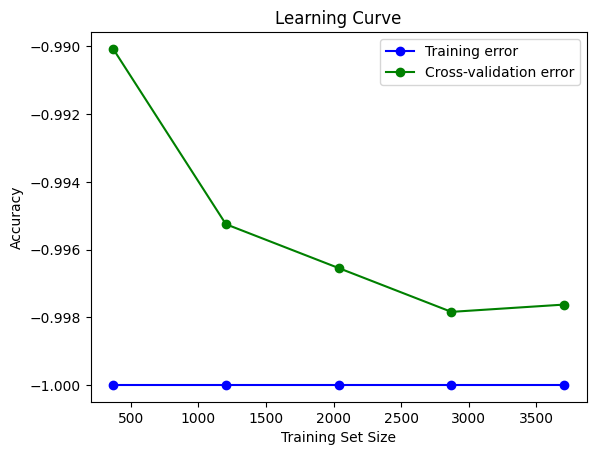

In [30]:
#Mendeteksi overfitting menggunakan learning curve pada Random Forest
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

model = rf_classifier

# Menghitung learning curve
train_sizes, train_scores, test_scores = learning_curve(model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)

# Menghitung rata-rata dan standar deviasi
train_mean = -np.mean(train_scores, axis=1)
test_mean = -np.mean(test_scores, axis=1)

# Plot learning curve
plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Training error")
plt.plot(train_sizes, test_mean, 'o-', color="green", label="Cross-validation error")
plt.title("Learning Curve")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

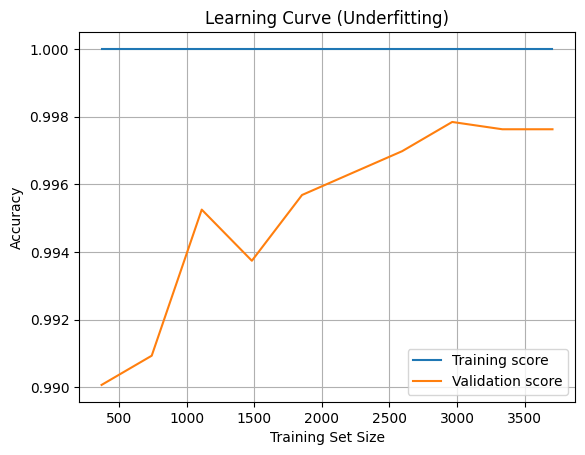

In [31]:
# Learning Curve untuk memeriksa performa pada berbagai ukuran data latih pada Random Forest (Underfitting)
train_sizes, train_scores, test_scores = learning_curve(model, X_train, y_train, cv=5, scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 10))

train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

# Plot Learning Curve
plt.figure()
plt.plot(train_sizes, train_scores_mean, label='Training score')
plt.plot(train_sizes, test_scores_mean, label='Validation score')
plt.ylabel('Accuracy')
plt.xlabel('Training Set Size')
plt.title('Learning Curve (Underfitting)')
plt.legend()
plt.grid(True)
plt.show()

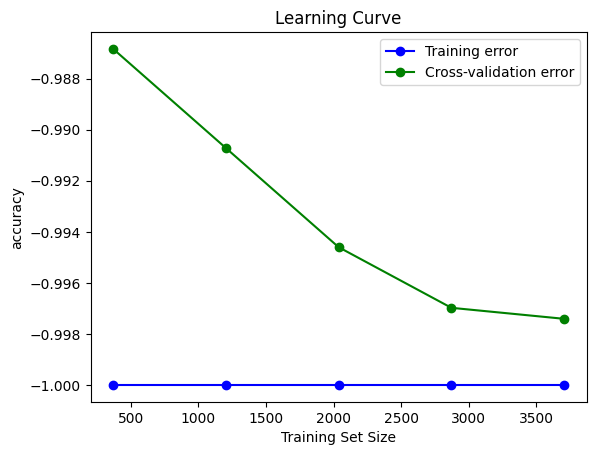

In [32]:
#Mendeteksi overfitting menggunakan learning curve pada Decision Tree
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

modeldt = dt_classifier

# Menghitung learning curve
train_sizes, train_scores, test_scores = learning_curve(modeldt, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)

# Menghitung rata-rata dan standar deviasi
train_mean = -np.mean(train_scores, axis=1)
test_mean = -np.mean(test_scores, axis=1)

# Plot learning curve
plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Training error")
plt.plot(train_sizes, test_mean, 'o-', color="green", label="Cross-validation error")
plt.title("Learning Curve")
plt.xlabel("Training Set Size")
plt.ylabel("accuracy")
plt.legend()
plt.show()

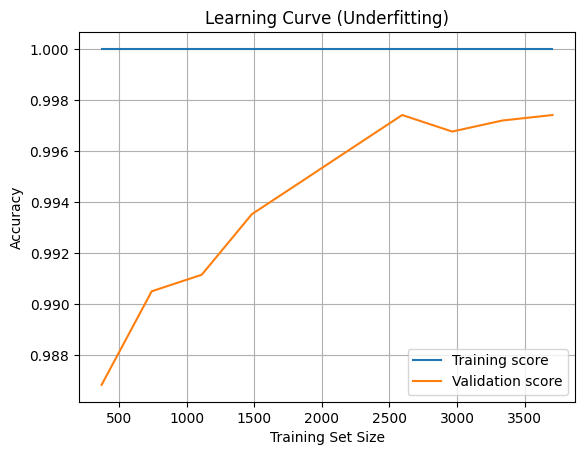

In [33]:
# Learning Curve untuk memeriksa performa pada berbagai ukuran data latih pada Decision Tree (Underfitting)
train_sizes, train_scores, test_scores = learning_curve(modeldt, X_train, y_train, cv=5, scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 10))

train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

# Plot Learning Curve
plt.figure()
plt.plot(train_sizes, train_scores_mean, label='Training score')
plt.plot(train_sizes, test_scores_mean, label='Validation score')
plt.ylabel('Accuracy')
plt.xlabel('Training Set Size')
plt.title('Learning Curve (Underfitting)')
plt.legend()
plt.grid(True)
plt.show()

#Hasil Analisis


1.    Model Random Forest:

  * Sebelum tuning: Accuracy = 0.998274, F1-Score = 0.998274

  * Setelah tuning (Grid Search): Accuracy = 0.998274, F1-Score = 0.998273

  * Analisis: Hyperparameter tuning tidak memberikan perubahan signifikan terhadap performa model. Accuracy dan F1-score tetap hampir sama, yang bisa menunjukkan bahwa model awal sudah cukup optimal atau tuning yang dilakukan belum menemukan kombinasi parameter yang lebih baik.

2.   Model Decision Tree:

  * Sebelum tuning: Accuracy = 0.997412, F1-Score = 0.997412

  * Setelah tuning (Grid Search): Accuracy = 0.997412, F1-Score = 0.997412

  * Analisis: Sama seperti pada Random Forest, tuning pada Decision Tree tidak memberikan perbedaan hasil. Hal ini bisa disebabkan oleh dataset yang sudah sesuai dengan parameter default atau model yang tidak terlalu sensitif terhadap perubahan parameter yang dicoba.

**Kesimpulan:**
* Hasil tuning tidak meningkatkan performa model secara signifikan.

* Kemungkinan tuning yang dilakukan tidak cukup luas atau model sudah mendekati performa terbaiknya dengan parameter default.

* Bisa mencoba pendekatan lain seperti menggunakan teknik tuning yang lain (misalnya Random Search atau Bayesian Optimization).

* Evaluasi tambahan seperti kurva pembelajaran atau validasi silang bisa membantu memastikan apakah model mengalami overfitting atau sudah optimal.


# Hasil Analisis Learning Curve Random Forest
* Gambar pertama menunjukkan indikasi overfitting, yang berarti model terlalu menyesuaikan diri dengan data pelatihan dan tidak dapat bekerja dengan baik pada data baru.

* Gambar kedua menunjukkan underfitting, yang berarti model belum cukup belajar dari data pelatihan sehingga prediksinya masih kurang baik.

* Solusi terbaik bergantung pada kondisi dataset dan eksperimen tambahan, seperti tuning hyperparameter yang lebih luas atau mencoba teknik ensemble lainnya.

# Hasil Analisis Learning Curve Decision Tree
* Gambar pertama menunjukkan indikasi overfitting, yang berarti model terlalu menyesuaikan diri dengan data pelatihan dan tidak dapat bekerja dengan baik pada data baru.

* Gambar kedua menunjukkan underfitting, yang berarti model belum cukup belajar dari data pelatihan sehingga prediksinya masih kurang baik.

* Pemilihan hyperparameter yang optimal sangat penting untuk menyeimbangkan kompleksitas model.



